<div style="background: linear-gradient(135deg, #880e4f 0%, #ad1457 50%, #c2185b 100%); padding: 40px 30px; border-radius: 12px; margin-bottom: 30px;">
  <h1 style="color:#ffffff; font-size:2.2em; font-weight:700; margin:0 0 10px 0;">Зертханалық Жұмыс 3</h1>
  <h2 style="color:#f8bbd0; font-size:1.4em; font-weight:400; margin:0 0 16px 0;">Нейрожелі Автоэнкодерлер жəне Бағалау Метрикалары</h2>
  <p style="color:#fce4ec; font-size:1em; margin:0;">DAE · VAE · Masked Loss · Diversity · Novelty · Coverage · Serendipity · Accuracy-Diversity Tradeoff</p>
</div>

## Кіріспе

Нейрожелі автоэнкодерлер ұсыныс жүйелерінде пайдаланушы рейтинг векторын тығыз латентті кеңістікке сығымдап, содан кейін толық рейтинг матрицасын болжайды.

**DAE** (Denoising Autoencoder) — кіріске dropout шуы қосылып, модель тазаланған нəтиже беруді үйренеді. Ушулы кіріс → тұтас болжам.

**VAE** (Variational Autoencoder) — латентті кеңістіктегі үлестіримнен сэмплдейді: z ~ N(μ, σ²). KL дивергенция арқылы латентті кеңістікті реттейді.

Beyond-accuracy метрикалар ұсыным тізімінің пайдаланушы тəжірибесіне сəйкестігін өлшейді — RMSE-ге қосымша.

## Оқу Мақсаттары

- DAE архитектурасын masked loss (тек белгілі рейтингтер бойынша) арқылы үйрете аласыз
- VAE үшін reparameterization trick жəне ELBO шығынын іске асыра аласыз
- DAE мен VAE нəтижелерін RMSE жəне ұсыным сапасы бойынша салыстыра аласыз
- Diversity, Novelty, Coverage, Serendipity метрикаларын əр əдіс үшін есептей аласыз
- Accuracy-diversity tradeoff графигін жасай аласыз

**Болжалды орындалу уақыты: 20 минут**

## 1-бөлім: Кітапханаларды Импорттау

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


## 2-бөлім: Деректерді Жасау

In [2]:
N_USERS, N_ITEMS = 400, 200
N_GENRES = 6
GENRES   = ['Экшн','Комедия','Драма','Ғылыми фантастика','Романтика','Триллер']

item_genre = np.zeros((N_ITEMS, N_GENRES))
for i in range(N_ITEMS):
    chosen = np.random.choice(N_GENRES, np.random.randint(1,3), replace=False)
    item_genre[i, chosen] = 1

user_prefs  = np.random.dirichlet(np.ones(N_GENRES)*2, N_USERS)
true_affin  = user_prefs @ item_genre.T
true_affin  = 1 + 4*(true_affin - true_affin.min())/(true_affin.max()-true_affin.min())

DENSITY = 0.08
mask    = np.random.binomial(1, DENSITY, (N_USERS, N_ITEMS)).astype(bool)
R       = np.where(mask, true_affin + np.random.randn(N_USERS, N_ITEMS)*0.25, 0.0)
R       = np.clip(R, 0, 5) * mask

# Өнім сипаттамалары (метрикалар үшін)
item_pop = (R > 0).sum(axis=0).astype(float)

print(f"Матрица: {N_USERS}×{N_ITEMS}, тығыздық={mask.mean():.2%}")
print(f"Орташа рейтинг: {R[R>0].mean():.3f}")

Матрица: 400×200, тығыздық=7.86%
Орташа рейтинг: 2.196


## 3-бөлім: DAE — Denoising Autoencoder

DAE рейтинг матрицасы үшін:
- Кіріс: пайдаланушы рейтинг векторы (N_ITEMS,) — сирек
- Dropout шуы қосылады (кіріс деңгейінде)
- Шығыс: толық рейтинг болжамы (N_ITEMS,)
- Шығын: тек белгілі рейтингтерде MSE

In [3]:
def build_dae(n_items, hidden_dims, dropout_rate=0.5, activation='selu'):
    """
    Denoising Autoencoder ұсыныс жүйесі.
    Симметриялы encoder-decoder архитектурасы.
    """
    inp = keras.Input(shape=(n_items,), name='user_ratings')

    # Шу қосу (dropout as noise)
    x = layers.Dropout(dropout_rate, name='input_dropout')(inp)

    # Encoder
    for i, dim in enumerate(hidden_dims):
        x = layers.Dense(dim, name=f'enc_{i+1}')(x)
        x = layers.LayerNormalization(name=f'ln_enc_{i+1}')(x)
        x = layers.Activation(activation, name=f'act_enc_{i+1}')(x)

    # Decoder (симметриялы)
    for i, dim in enumerate(reversed(hidden_dims)):
        x = layers.Dense(dim, name=f'dec_{i+1}')(x)
        x = layers.LayerNormalization(name=f'ln_dec_{i+1}')(x)
        x = layers.Activation(activation, name=f'act_dec_{i+1}')(x)

    # Шығыс: [0, 5] диапазонына
    out = layers.Dense(n_items, activation='sigmoid', name='output')(x)
    out = layers.Lambda(lambda z: z * 5.0, name='scale')(out)

    return keras.Model(inp, out, name='DAE')

print("build_dae() анықталды.")

build_dae() анықталды.


In [4]:
def masked_mse(y_true, y_pred):
    mask = tf.cast(y_true > 0, tf.float32)
    squared = tf.square(y_true - y_pred)
    return tf.reduce_sum(mask * squared) / (tf.reduce_sum(mask) + 1e-8)

dae = build_dae(N_ITEMS, hidden_dims=[256, 128, 64], dropout_rate=0.5)
dae.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=masked_mse
)
dae.summary()


Model: "DAE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ user_ratings (InputLayer)       │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ input_dropout (Dropout)         │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_1 (Dense)                   │ (None, 256)            │        51,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ln_enc_1 (LayerNormalization)   │ (None, 256)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_enc_1 (Activation)          │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_2 (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ln_enc_2 (LayerNormalization)   │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_enc_2 (Activation)          │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_3 (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ln_enc_3 (LayerNormalization)   │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_enc_3 (Activation)          │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_1 (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ln_dec_1 (LayerNormalization)   │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_dec_1 (Activation)          │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_2 (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ln_dec_2 (LayerNormalization)   │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_dec_2 (Activation)          │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_3 (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ln_dec_3 (LayerNormalization)   │ (None, 256)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_dec_3 (Activation)          │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 200)            │        51,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ scale (Lambda)                  │ (None, 200)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 191,304 (747.28 KB)

 Trainable params: 191,304 (747.28 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
print("DAE үйретілуде...")
hist_dae = dae.fit(
    R, R,
    epochs=40,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

R_dae = dae.predict(R, verbose=0)
err_d = (R - R_dae) * mask
rmse_dae = np.sqrt((err_d**2).sum() / mask.sum())
print(f"DAE Train RMSE: {rmse_dae:.4f}")

DAE үйретілуде...
Epoch 1/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 94ms/step - loss: 1.6493 - val_loss: 1.2415
Epoch 2/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 1.0923 - val_loss: 0.9345
Epoch 3/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.7433 - val_loss: 0.6827
Epoch 4/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.5488 - val_loss: 0.5125
Epoch 5/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.4270 - val_loss: 0.4195
Epoch 6/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.3712 - val_loss: 0.3980
Epoch 7/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.3427 - val_loss: 0.3975
Epoch 8/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.3261 - val_loss: 0.3881
Epoch 9/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.3160 - val_loss: 0.3694
Epoch 10/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.3055 - val_loss: 0.3794
Epoch 11/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.2987 - val_loss: 0.3905
Epoch 12/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.2885 - 

## 4-бөлім: VAE — Variational Autoencoder

VAE латентті кеңістікте **ықтималдық үлестірімін** үйренеді:
```
z ~ N(μ(x), σ²(x))
ELBO = E[log p(x|z)] - KL(q(z|x) || p(z))
     = Reconstruction Loss + KL Divergence
```
**Reparameterization trick**: z = μ + σ·ε, ε ~ N(0,1) — градиент есептеуге мүмкіндік береді.

In [6]:
class VAERecommender(keras.Model):
    """
    VAE-негізді ұсыныс жүйесі.
    ELBO = Masked Reconstruction Loss + β·KL Divergence
    """
    def __init__(self, n_items, latent_dim=64,
                 hidden_dims=None, beta=0.5, dropout_rate=0.5):
        super().__init__()
        if hidden_dims is None:
            hidden_dims = [256, 128]
        self.n_items      = n_items
        self.latent_dim   = latent_dim
        self.beta         = beta
        self.dropout_rate = dropout_rate

        # Encoder қабаттары
        self.enc_dropout  = layers.Dropout(dropout_rate)
        self.enc_dense    = [
            layers.Dense(d, activation='selu') for d in hidden_dims
        ]
        self.mu_layer     = layers.Dense(latent_dim, name='mu')
        self.logvar_layer = layers.Dense(latent_dim, name='log_var')

        # Decoder қабаттары
        self.dec_dense    = [
            layers.Dense(d, activation='selu') for d in reversed(hidden_dims)
        ]
        self.dec_out      = layers.Dense(n_items, activation='sigmoid')

        self.total_loss_tracker    = keras.metrics.Mean(name='total_loss')
        self.recon_loss_tracker    = keras.metrics.Mean(name='recon_loss')
        self.kl_loss_tracker       = keras.metrics.Mean(name='kl_loss')

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def encode(self, x, training=False):
        x = self.enc_dropout(x, training=training)
        for layer in self.enc_dense:
            x = layer(x)
        mu     = self.mu_layer(x)
        logvar = self.logvar_layer(x)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        """z = mu + sigma * epsilon, epsilon ~ N(0, I)"""
        eps   = tf.random.normal(tf.shape(mu))
        sigma = tf.exp(0.5 * logvar)
        return mu + sigma * eps

    def decode(self, z):
        x = z
        for layer in self.dec_dense:
            x = layer(x)
        return self.dec_out(x) * 5.0

    def train_step(self, data):
        x, y = data
        with tf.GradientTape() as tape:
            mu, logvar  = self.encode(x, training=True)
            z           = self.reparameterize(mu, logvar)
            x_hat       = self.decode(z)

            # Masked reconstruction loss
            mask_t      = tf.cast(y > 0, tf.float32)
            recon_loss  = tf.reduce_sum(
                mask_t * tf.square(y - x_hat)
            ) / (tf.reduce_sum(mask_t) + 1e-8)

            # KL divergence: -0.5 * sum(1 + log(σ²) - μ² - σ²)
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(1 + logvar - tf.square(mu) - tf.exp(logvar), axis=1)
            )

            total_loss = recon_loss + self.beta * kl_loss

        grads = tape.gradient(total_loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

    def predict_ratings(self, x):
        mu, logvar = self.encode(x, training=False)
        z  = mu   # inference кезінде μ пайдаланамыз
        return self.decode(z).numpy()

print("VAERecommender класы анықталды.")

VAERecommender класы анықталды.


In [7]:
vae = VAERecommender(
    n_items=N_ITEMS,
    latent_dim=64,
    hidden_dims=[256, 128],
    beta=0.5
)
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))
print("VAE компиляцияланды.")


VAE компиляцияланды.


In [8]:
print("VAE үйретілуде...")
hist_vae = vae.fit(
    R, R,
    epochs=40,
    batch_size=64,
    verbose=1
)

R_vae = vae.predict_ratings(R)
err_v = (R - R_vae) * mask
rmse_vae = np.sqrt((err_v**2).sum() / mask.sum())
print(f"VAE Train RMSE: {rmse_vae:.4f}")

VAE үйретілуде...
Epoch 1/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - kl_loss: 61.5332 - recon_loss: 1.7183 - total_loss: 32.4849
Epoch 2/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - kl_loss: 37.4261 - recon_loss: 1.3443 - total_loss: 20.0574 
Epoch 3/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - kl_loss: 25.8225 - recon_loss: 1.1385 - total_loss: 14.0497 
Epoch 4/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - kl_loss: 18.9062 - recon_loss: 1.0243 - total_loss: 10.4774 
Epoch 5/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - kl_loss: 14.3059 - recon_loss: 0.9181 - total_loss: 8.0710 
Epoch 6/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - kl_loss: 11.2422 - recon_loss: 0.8324 - total_loss: 6.4535 
Epoch 7/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - kl_loss: 9.0476 - recon_loss: 0.7871 - total_loss: 5.3109  
Epoch 8/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - kl_loss: 7.3534 - recon_loss: 0.7351 - total_loss: 4.4118 
Epoch 9/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - kl_loss: 6.0685 - recon_loss: 0.6875 - total_loss:

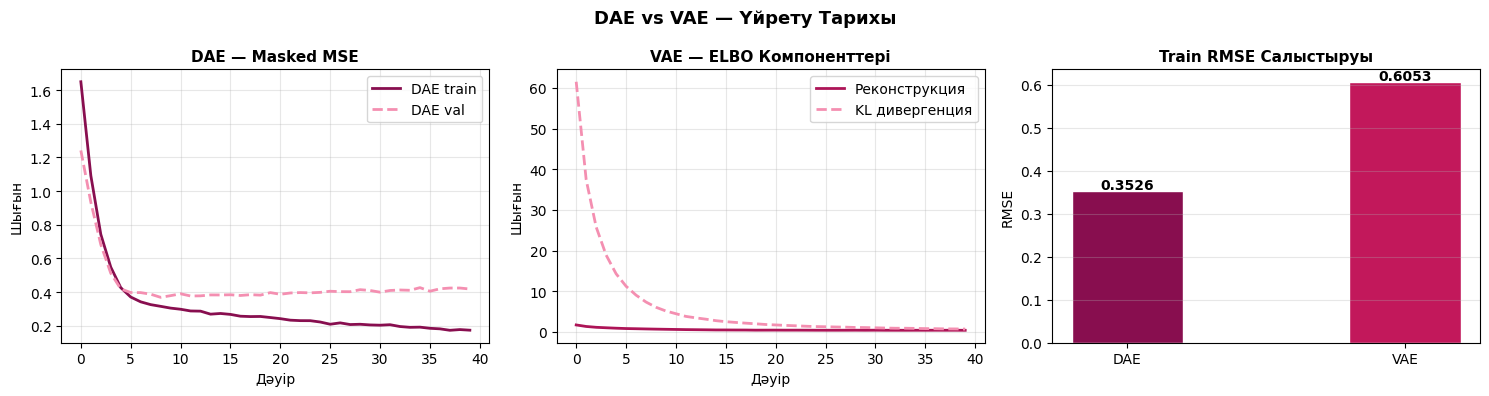

In [9]:
# DAE vs VAE тарих салыстыруы
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('DAE vs VAE — Үйрету Тарихы', fontsize=13, fontweight='bold')

axes[0].plot(hist_dae.history['loss'],     linewidth=2, color='#880e4f', label='DAE train')
axes[0].plot(hist_dae.history['val_loss'], linewidth=2, color='#f48fb1', linestyle='--', label='DAE val')
axes[0].set_title('DAE — Masked MSE', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Дəуір')
axes[0].set_ylabel('Шығын')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(hist_vae.history['recon_loss'], linewidth=2, color='#ad1457', label='Реконструкция')
axes[1].plot(hist_vae.history['kl_loss'],    linewidth=2, color='#f48fb1', linestyle='--', label='KL дивергенция')
axes[1].set_title('VAE — ELBO Компоненттері', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Дəуір')
axes[1].set_ylabel('Шығын')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# RMSE салыстыру
axes[2].bar(['DAE', 'VAE'], [rmse_dae, rmse_vae],
            color=['#880e4f', '#c2185b'], edgecolor='white', width=0.4)
for i, (name, val) in enumerate([('DAE', rmse_dae), ('VAE', rmse_vae)]):
    axes[2].text(i, val + 0.005, f'{val:.4f}', ha='center', fontweight='bold')
axes[2].set_title('Train RMSE Салыстыруы', fontsize=11, fontweight='bold')
axes[2].set_ylabel('RMSE')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 5-бөлім: Beyond-Accuracy Метрикалар — Толық Іске Асыру

Ұсыным сапасын тек RMSE-мен емес, 4 қосымша метрикамен өлшейміз.

In [10]:
# ── Метрика функциялары ─────────────────────────────────────────────────

def catalog_coverage(all_recs, n_items):
    """Coverage: бірегей ұсынылған өнімдер / барлық өнімдер."""
    unique = set(item for recs in all_recs for item in recs)
    return len(unique) / n_items

def intra_list_diversity(recs, item_features):
    """Diversity: 1 - орт. косинустық ұқсастық."""
    if len(recs) < 2:
        return 0.0
    feats = item_features[recs]
    sim   = cosine_similarity(feats)
    n     = len(recs)
    avg   = (sim.sum() - n) / (n*(n-1) + 1e-10)
    return 1 - avg

def novelty_score(recs, item_pop, n_users):
    """Novelty: -log2 p(item), яғни сирек өнімге жоғары скор."""
    if not recs:
        return 0.0
    return np.mean([
        -np.log2(max(item_pop[i] / n_users, 1e-10))
        for i in recs
    ])

def serendipity_score(recs, relevant, unexpected):
    """Serendipity: пайдалы ∩ күтпеген."""
    return len(set(recs) & set(relevant) & set(unexpected)) / (len(recs) + 1e-10)

def precision_at_k(recs, relevant, k):
    rec_k = list(recs)[:k]
    return len(set(rec_k) & set(relevant)) / k

def ndcg_at_k(recs, relevant, k):
    rec_k = list(recs)[:k]
    dcg   = sum(1/np.log2(i+2) for i,r in enumerate(rec_k) if r in relevant)
    idcg  = sum(1/np.log2(i+2) for i in range(min(len(relevant), k)))
    return dcg / (idcg + 1e-10)

print("Барлық метрика функциялары анықталды.")

Барлық метрика функциялары анықталды.


In [11]:
K_EVAL = 10
N_EVAL = 60

u_means = np.nanmean(np.where(R > 0, R, np.nan), axis=1, keepdims=True)
R_c = np.where(mask, R - u_means, 0.0)
svd_m = TruncatedSVD(n_components=20, random_state=42)
U_svd = svd_m.fit_transform(R_c)
R_svd = np.clip(U_svd @ np.diag(svd_m.singular_values_) @ svd_m.components_ + u_means, 1, 5)

pop_order = np.argsort(item_pop)[::-1]
pop_median = np.median(item_pop)
unexp_items = np.where(item_pop < pop_median)[0].tolist()

def get_top_n(R_pred, R_obs, u, top_n):
    unr = np.where(R_obs[u] == 0)[0]
    return unr[np.argsort(R_pred[u, unr])[::-1][:top_n]].tolist()

models = {
    'SVD': R_svd,
    'DAE': R_dae,
    'VAE': R_vae,
}

full_results = {}

print(f"{'Əдіс':<12} {'P@K':>8} {'NDCG@K':>8} {'Coverage':>10} {'Diversity':>11} {'Novelty':>9} {'Serendip':>10}")
print("-" * 72)

for name, R_pred in list(models.items()) + [('Popularity', None)]:
    prec_list, ndcg_list, div_list, nov_list, ser_list = [], [], [], [], []
    all_recs_list = []

    for u in range(N_EVAL):
        if name == 'Popularity':
            unr = np.where(R[u] == 0)[0]
            recs = [i for i in pop_order if i in unr][:K_EVAL]
        else:
            recs = get_top_n(R_pred, R, u, K_EVAL)

        relevant = np.where(true_affin[u] > 4.0)[0].tolist()

        prec_list.append(precision_at_k(recs, relevant, K_EVAL))
        ndcg_list.append(ndcg_at_k(recs, relevant, K_EVAL))
        div_list.append(intra_list_diversity(recs, item_genre))
        nov_list.append(novelty_score(recs, item_pop, N_USERS))
        ser_list.append(serendipity_score(recs, relevant, unexp_items))
        all_recs_list.append(recs)

    cov = catalog_coverage(all_recs_list, N_ITEMS)
    full_results[name] = {
        'Precision@K': np.mean(prec_list),
        'NDCG@K': np.mean(ndcg_list),
        'Coverage': cov,
        'Diversity': np.mean(div_list),
        'Novelty': np.mean(nov_list),
        'Serendipity': np.mean(ser_list),
    }

    r = full_results[name]
    print(f"{name:<12} {r['Precision@K']:>8.4f} {r['NDCG@K']:>8.4f} {r['Coverage']:>10.3f} {r['Diversity']:>11.4f} {r['Novelty']:>9.4f} {r['Serendipity']:>10.4f}")


Əдіс              P@K   NDCG@K   Coverage   Diversity   Novelty   Serendip
------------------------------------------------------------------------
SVD            0.0283   0.0350      0.615      0.5869    3.6049     0.0167
DAE            0.0217   0.0266      0.465      0.6293    3.7062     0.0100
VAE            0.0217   0.0300      0.100      0.5372    3.7258     0.0200
Popularity     0.0083   0.0130      0.070      0.7422    3.2495     0.0000


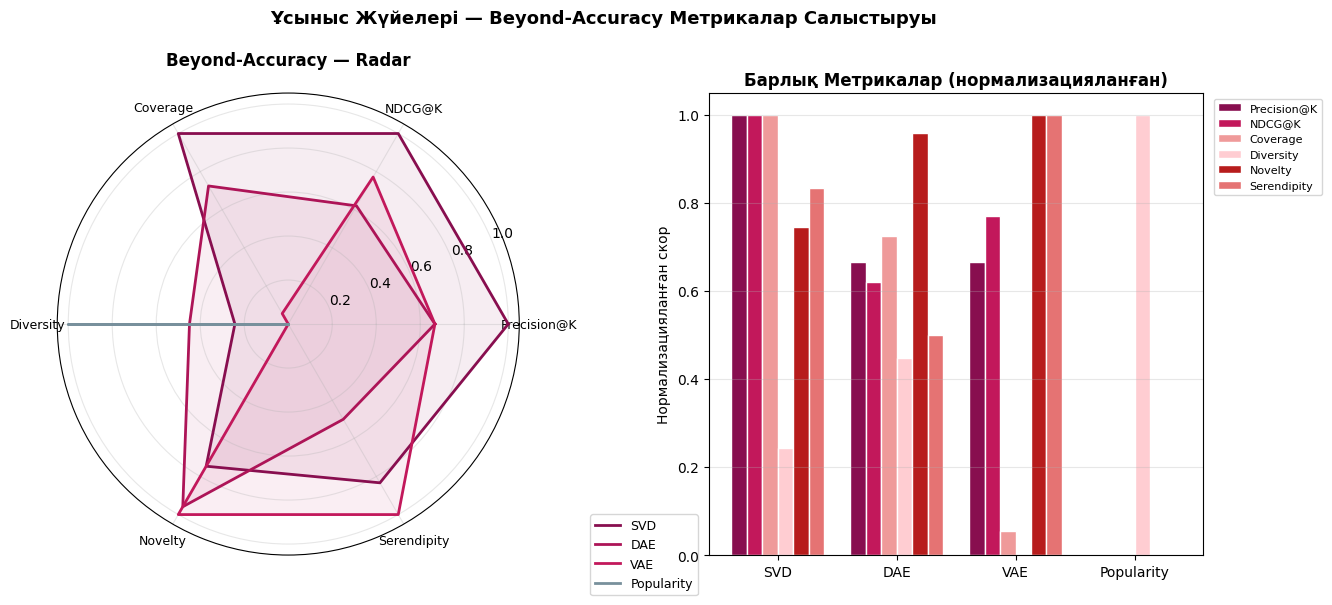

In [12]:
metric_keys = ['Precision@K', 'NDCG@K', 'Coverage', 'Diversity', 'Novelty', 'Serendipity']
model_names = list(full_results.keys())
colors_m = ['#880e4f', '#ad1457', '#c2185b', '#78909c']

fig = plt.figure(figsize=(15, 6))
gs = fig.add_gridspec(1, 2, wspace=0.35)

ax_r = fig.add_subplot(gs[0], polar=True)
angles = np.linspace(0, 2 * np.pi, len(metric_keys), endpoint=False).tolist()
angles += angles[:1]

norm_results = {}
for metric in metric_keys:
    vals = [full_results[m][metric] for m in model_names]
    mn, mx = min(vals), max(vals)
    for m in model_names:
        norm_results.setdefault(m, {})[metric] = (
            (full_results[m][metric] - mn) / (mx - mn + 1e-10)
        )

for name, color in zip(model_names, colors_m):
    vals = [norm_results[name][m] for m in metric_keys] + [norm_results[name][metric_keys[0]]]
    ax_r.plot(angles, vals, linewidth=2, label=name, color=color)
    ax_r.fill(angles, vals, alpha=0.07, color=color)

ax_r.set_xticks(angles[:-1])
ax_r.set_xticklabels(metric_keys, fontsize=9)
ax_r.set_title('Beyond-Accuracy — Radar', fontsize=12, fontweight='bold', pad=20)
ax_r.legend(loc='lower right', bbox_to_anchor=(1.4, -0.1), fontsize=9)
ax_r.grid(True, alpha=0.3)

ax_b = fig.add_subplot(gs[1])
x = np.arange(len(model_names))
width = 0.13
bar_colors = ['#880e4f', '#c2185b', '#ef9a9a', '#ffcdd2', '#b71c1c', '#e57373']

for i, (metric, bc) in enumerate(zip(metric_keys, bar_colors)):
    vals = [full_results[m][metric] for m in model_names]
    mn, mx = min(vals), max(vals)
    vals_n = [(v - mn) / (mx - mn + 1e-10) for v in vals]
    ax_b.bar(x + i * width - 2.5 * width, vals_n, width,
             label=metric, color=bc, edgecolor='white')

ax_b.set_xticks(x)
ax_b.set_xticklabels(model_names, fontsize=10)
ax_b.set_title('Барлық Метрикалар (нормализацияланған)', fontsize=12, fontweight='bold')
ax_b.set_ylabel('Нормализацияланған скор')
ax_b.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax_b.grid(True, alpha=0.3, axis='y')

plt.suptitle('Ұсыныс Жүйелері — Beyond-Accuracy Метрикалар Салыстыруы',
             fontsize=13, fontweight='bold', y=1.02)
plt.show()


## 6-бөлім: Accuracy-Diversity Tradeoff

Dropout=0.0: P@K=0.0200, Div=0.6658
Dropout=0.2: P@K=0.0133, Div=0.6677
Dropout=0.4: P@K=0.0117, Div=0.6329
Dropout=0.6: P@K=0.0200, Div=0.6222
Dropout=0.8: P@K=0.0083, Div=0.6467


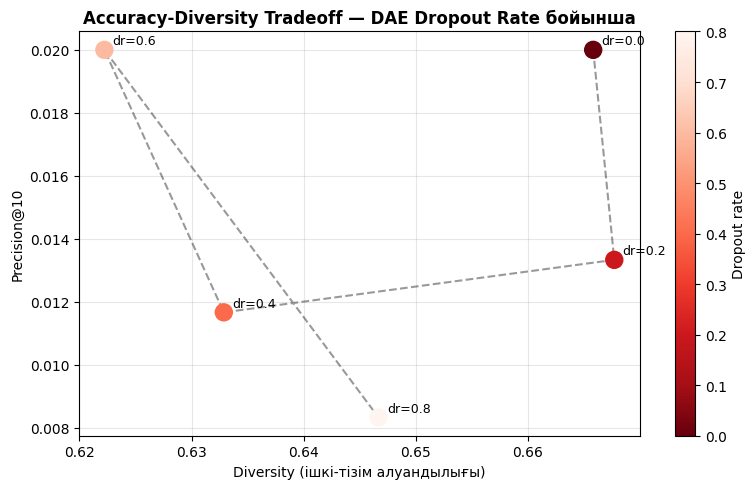

In [13]:
dropout_rates = [0.0, 0.2, 0.4, 0.6, 0.8]
tradeoff_prec = []
tradeoff_div = []

for dr in dropout_rates:
    dae_tmp = build_dae(N_ITEMS, hidden_dims=[128, 64], dropout_rate=dr)
    dae_tmp.compile(optimizer='adam', loss=masked_mse)
    dae_tmp.fit(R, R, epochs=20, batch_size=64, verbose=0)
    R_tmp = dae_tmp.predict(R, verbose=0)

    prec_tmp, div_tmp = [], []
    for u in range(N_EVAL):
        recs = get_top_n(R_tmp, R, u, K_EVAL)
        relevant = np.where(true_affin[u] > 4.0)[0].tolist()
        prec_tmp.append(precision_at_k(recs, relevant, K_EVAL))
        div_tmp.append(intra_list_diversity(recs, item_genre))

    tradeoff_prec.append(np.mean(prec_tmp))
    tradeoff_div.append(np.mean(div_tmp))
    print(f"Dropout={dr}: P@K={tradeoff_prec[-1]:.4f}, Div={tradeoff_div[-1]:.4f}")

plt.figure(figsize=(8, 5))
sc = plt.scatter(tradeoff_div, tradeoff_prec, c=dropout_rates,
                 cmap='Reds_r', s=150, zorder=5)
plt.colorbar(sc, label='Dropout rate')
for dr, div, prec in zip(dropout_rates, tradeoff_div, tradeoff_prec):
    plt.annotate(f'dr={dr}', (div, prec),
                 textcoords='offset points', xytext=(6, 4), fontsize=9)
plt.plot(tradeoff_div, tradeoff_prec, 'k--', alpha=0.4, linewidth=1.5)
plt.title('Accuracy-Diversity Tradeoff — DAE Dropout Rate бойынша',
          fontsize=12, fontweight='bold')
plt.xlabel('Diversity (ішкі-тізім алуандылығы)')
plt.ylabel('Precision@10')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


β=0.0: Div=0.6407, Nov=3.6877
β=0.1: Div=0.5670, Nov=3.7127
β=0.5: Div=0.6052, Nov=3.6925
β=1.0: Div=0.6263, Nov=3.7263
β=2.0: Div=0.6191, Nov=3.6732


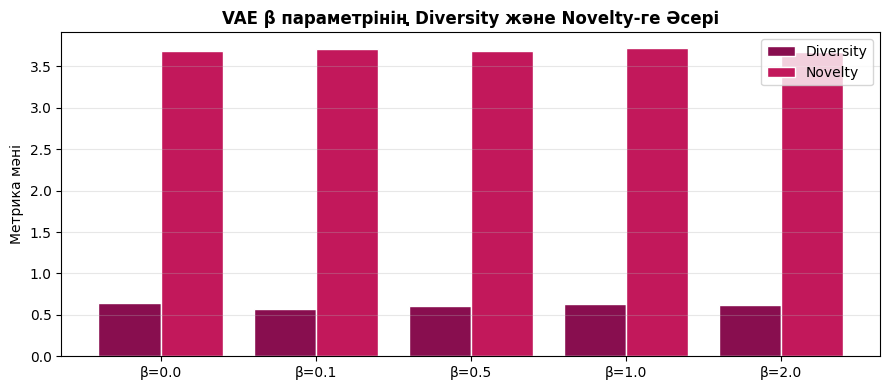

In [14]:
beta_values = [0.0, 0.1, 0.5, 1.0, 2.0]
beta_div = []
beta_nov = []

for beta_val in beta_values:
    vae_tmp = VAERecommender(
        N_ITEMS, latent_dim=32, hidden_dims=[128, 64], beta=beta_val
    )
    vae_tmp.compile(optimizer=keras.optimizers.Adam(1e-3))
    vae_tmp.fit(R, R, epochs=20, batch_size=64, verbose=0)
    R_tmp = vae_tmp.predict_ratings(R)

    div_tmp, nov_tmp = [], []
    for u in range(N_EVAL):
        recs = get_top_n(R_tmp, R, u, K_EVAL)
        div_tmp.append(intra_list_diversity(recs, item_genre))
        nov_tmp.append(novelty_score(recs, item_pop, N_USERS))

    beta_div.append(np.mean(div_tmp))
    beta_nov.append(np.mean(nov_tmp))
    print(f"β={beta_val}: Div={beta_div[-1]:.4f}, Nov={beta_nov[-1]:.4f}")

x = np.arange(len(beta_values))
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - 0.2, beta_div, 0.4, label='Diversity', color='#880e4f', edgecolor='white')
ax.bar(x + 0.2, beta_nov, 0.4, label='Novelty', color='#c2185b', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels([f'β={b}' for b in beta_values])
ax.set_title('VAE β параметрінің Diversity жəне Novelty-ге Əсері',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Метрика мəні')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


## 7-бөлім: Жинақты Кесте

In [15]:
# Барлық зертхана бойынша əдістер жинақ кестесі
summary = pd.DataFrame([
    {
        'Əдіс':               'SVD / FunkSVD',
        'Тип':                'MF',
        'Кіріс':              'Explicit рейтинг',
        'Латентті кеңістік':  'Линейлік',
        'Интерпретация':      'Орташа',
        'Cold Start':         'Мəселе бар',
    },
    {
        'Əдіс':               'NMF',
        'Тип':                'MF',
        'Кіріс':              'Теріс емес матрица',
        'Латентті кеңістік':  'Линейлік, теріс емес',
        'Интерпретация':      'Жоғары (топиктер)',
        'Cold Start':         'Мəселе бар',
    },
    {
        'Əдіс':               'Content-based',
        'Тип':                'CB',
        'Кіріс':              'Өнім мəтіні/жанры',
        'Латентті кеңістік':  'TF-IDF кеңістігі',
        'Интерпретация':      'Жоғары',
        'Cold Start':         'Шешеді (өнім үшін)',
    },
    {
        'Əдіс':               'Weighted Hybrid',
        'Тип':                'Hybrid',
        'Кіріс':              'MF + CB',
        'Латентті кеңістік':  'Аралас',
        'Интерпретация':      'Орташа',
        'Cold Start':         'Ішінара шешеді',
    },
    {
        'Əдіс':               'DAE',
        'Тип':                'Нейрожелі',
        'Кіріс':              'Рейтинг вектор',
        'Латентті кеңістік':  'Линейлік емес',
        'Интерпретация':      'Төмен',
        'Cold Start':         'Мəселе бар',
    },
    {
        'Əдіс':               'VAE',
        'Тип':                'Нейрожелі',
        'Кіріс':              'Рейтинг вектор',
        'Латентті кеңістік':  'Ықтималдық (N(μ,σ²))',
        'Интерпретация':      'Өте төмен',
        'Cold Start':         'Мəселе бар',
    },
])

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 30)
pd.set_option('display.width', 160)
print(summary.to_string(index=False))

           Əдіс       Тип              Кіріс    Латентті кеңістік     Интерпретация         Cold Start
  SVD / FunkSVD        MF   Explicit рейтинг             Линейлік            Орташа         Мəселе бар
            NMF        MF Теріс емес матрица Линейлік, теріс емес Жоғары (топиктер)         Мəселе бар
  Content-based        CB  Өнім мəтіні/жанры     TF-IDF кеңістігі            Жоғары Шешеді (өнім үшін)
Weighted Hybrid    Hybrid            MF + CB               Аралас            Орташа     Ішінара шешеді
            DAE Нейрожелі     Рейтинг вектор        Линейлік емес             Төмен         Мəселе бар
            VAE Нейрожелі     Рейтинг вектор Ықтималдық (N(μ,σ²))         Өте төмен         Мəселе бар


## 8-бөлім: Рефлексиялық Сұрақтар

**Сұрақ 1.** DAE-дің Denoising мəні неде? Dropout шуын кіріске қосу əдеттегі Dropout-тан қалай ерекшеленеді?

DAE-дің мағынасы - кірісті аздап бұзып берсек те, модель дұрыс нұсқасын қайта шығаруды үйренеді. Яғни ол жай ғана жаттап алмай, жалпы байланысты түсінуге тырысады. Кәдімгі dropout overfitting-ті азайту үшін қолданылады, ал мұнда ол арнайы шу беру үшін керек.

**Сұрақ 2.** VAE-дің reparameterization trick-ы неліктен қажет? Тікелей z ~ N(μ,σ²) сэмплдеу жасасақ не болар еді?

Reparameterization trick керек, себебі модельді backpropagation арқылы үйретеміз. Егер z-ті бірден кездейсоқ алып қойсақ, градиент дұрыс өтпейді. Ал z = μ + σ·ε деп жазсақ, модель μ мен σ-ны үйрене алады.

**Сұрақ 3.** β (KL салмағы) артқанда Diversity жоғарылайды. Бұл неліктен? β = 0 болса VAE-ден не күтесіз?

β өскен сайын модель latent кеңістікті көбірек реттейді. Сол үшін ұсынымдар бір-біріне қатты ұқсап кетпей, әртүрлілеу бола бастайды. Ал β = 0 болса, модель негізі reconstruction-ға ғана жұмыс істеп, кәдімгі autoencoder сияқты болып кетеді.

**Сұрақ 4.** Serendipity метрикасын есептеу өте қиын. Оны A/B тест арқылы бағалауға болады ма? Сипаттаңыз.

Иә, болады. Мысалы, бір топқа кәдімгі ұсыным береміз, екінші топқа сәл тосын, бірақ пайдалы ұсыным береміз. Сосын CTR, басу саны, қарау уақыты немесе қайта келу сияқты көрсеткіштерді салыстырамыз. Егер адам күтпеген ұсынымдарға да жақсы жауап берсе, serendipity бар деуге болады.

**Сұрақ 5.** Accuracy-diversity tradeoff-ты бизнес тұрғысынан қалай шешесіз? Ыңғайлы тепе-теңдік бар ма?

Бизнеске тек дәлдік қана емес, қолданушыға қызық болу да маңызды. Егер жүйе үнемі бірдей нәрсе ұсына берсе, адам жалығып кетуі мүмкін. Сондықтан көбіне бір бөлігі дәл, бір бөлігі жаңа немесе әртүрлі ұсыным болатын баланс таңдалады. Сол тепе-теңдікті әдетте A/B тестпен қарайды.


## Жалпы Қорытынды: Жетілдірілген Ұсыныс Жүйелері Сериясы

Осы сериядағы төрт зертхананы аяқтай отырып, сіз ұсыныс жүйелерінің толық спектрін меңгердіңіз.

**Зертхана 0 — Шолу:** SVD, NMF, Content-based, Hybrid, DAE — бəрін бір дəптерде, Coverage/Diversity/Novelty/Serendipity radar chart.

**Зертхана 1 — SVD + NMF:** Сингулярлық мəн спектрі, 80/90/95% дисперсия K шектері, FunkSVD bias терминдерімен, NMF компонент-жанр байланысы, Jaccard ұқсастық.

**Зертхана 2 — Content-based + Hybrid:** TF-IDF item-item матрицасы, пайдаланушы профилі, Weighted/Cascade/Switching гибридті стратегиялары, адаптивті α, LOO Precision@K α іздеу.

**Зертхана 3 — Autoencoder + Метрикалар:** DAE masked loss, VAE ELBO = Recon + β·KL, dropout tradeoff scatter plot, β → diversity/novelty bar chart, толық 6 метрика radar + grouped bar салыстыруы.

<div style="background-color:#fce4ec; border-left:5px solid #c2185b; padding:15px 18px; border-radius:8px; margin-top:16px;">
<strong>Əрі қарай:</strong> Neural CF (NCF), BERT4Rec (трансформер-негізді), LightGCN (граф нейрожелі), Two-Tower модельдері, Reinforcement Learning for Recommendation — осы зертханалардың барлығы заманауи өнеркəсіптік жүйелерде іске асырылады.
</div>